# Exercise 07 : Heatmap




In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import (make_axes_locatable)

data = sqlite3.connect('../data/checking-logs.sqlite')

df = pd.read_sql_query("SELECT uid, timestamp FROM checker WHERE uid LIKE 'user_%'", data)

data.close()

## Подготовка данных к построению




In [2]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.day_name()

user_days = df.groupby(['uid', 'weekday']).size().reset_index(name='commits')
user_hours = df.groupby(['uid', 'hour']).size().reset_index(name='commits')

all_hours = pd.DataFrame({'hour': range(24)}).set_index('hour')
user_hours = all_hours.merge(user_hours, on='hour', how='right').fillna(0)

user_final_days = user_days.pivot_table(index='weekday', columns='uid', values='commits').fillna(0)
user_final_hours = user_hours.pivot_table(index='hour', columns='uid', values='commits').fillna(0)
user_final_days

uid,user_0,user_1,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,...,user_27,user_28,user_29,user_3,user_30,user_31,user_4,user_6,user_7,user_8
weekday,,,,,,,,,,,,,,,,,,,,,
Friday,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,7.0,1.0,59.0,3.0,35.0,61.0,0.0,0.0,0.0
Monday,3.0,0.0,0.0,0.0,2.0,3.0,50.0,0.0,10.0,8.0,...,0.0,0.0,9.0,46.0,2.0,5.0,35.0,1.0,0.0,0.0
Saturday,0.0,1.0,4.0,0.0,7.0,28.0,79.0,4.0,0.0,32.0,...,0.0,12.0,2.0,3.0,22.0,90.0,0.0,2.0,0.0,46.0
Sunday,0.0,43.0,2.0,8.0,76.0,23.0,26.0,20.0,31.0,0.0,...,27.0,32.0,26.0,8.0,21.0,7.0,45.0,9.0,0.0,26.0
Thursday,0.0,39.0,77.0,0.0,7.0,4.0,17.0,5.0,14.0,17.0,...,15.0,12.0,25.0,7.0,20.0,7.0,108.0,2.0,0.0,15.0
Tuesday,0.0,0.0,16.0,0.0,1.0,57.0,87.0,0.0,5.0,4.0,...,0.0,7.0,26.0,11.0,3.0,0.0,86.0,0.0,5.0,0.0
Wednesday,0.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,44.0,32.0,0.0,1.0,0.0,33.0,4.0,3.0,0.0


## Отрисовка графика





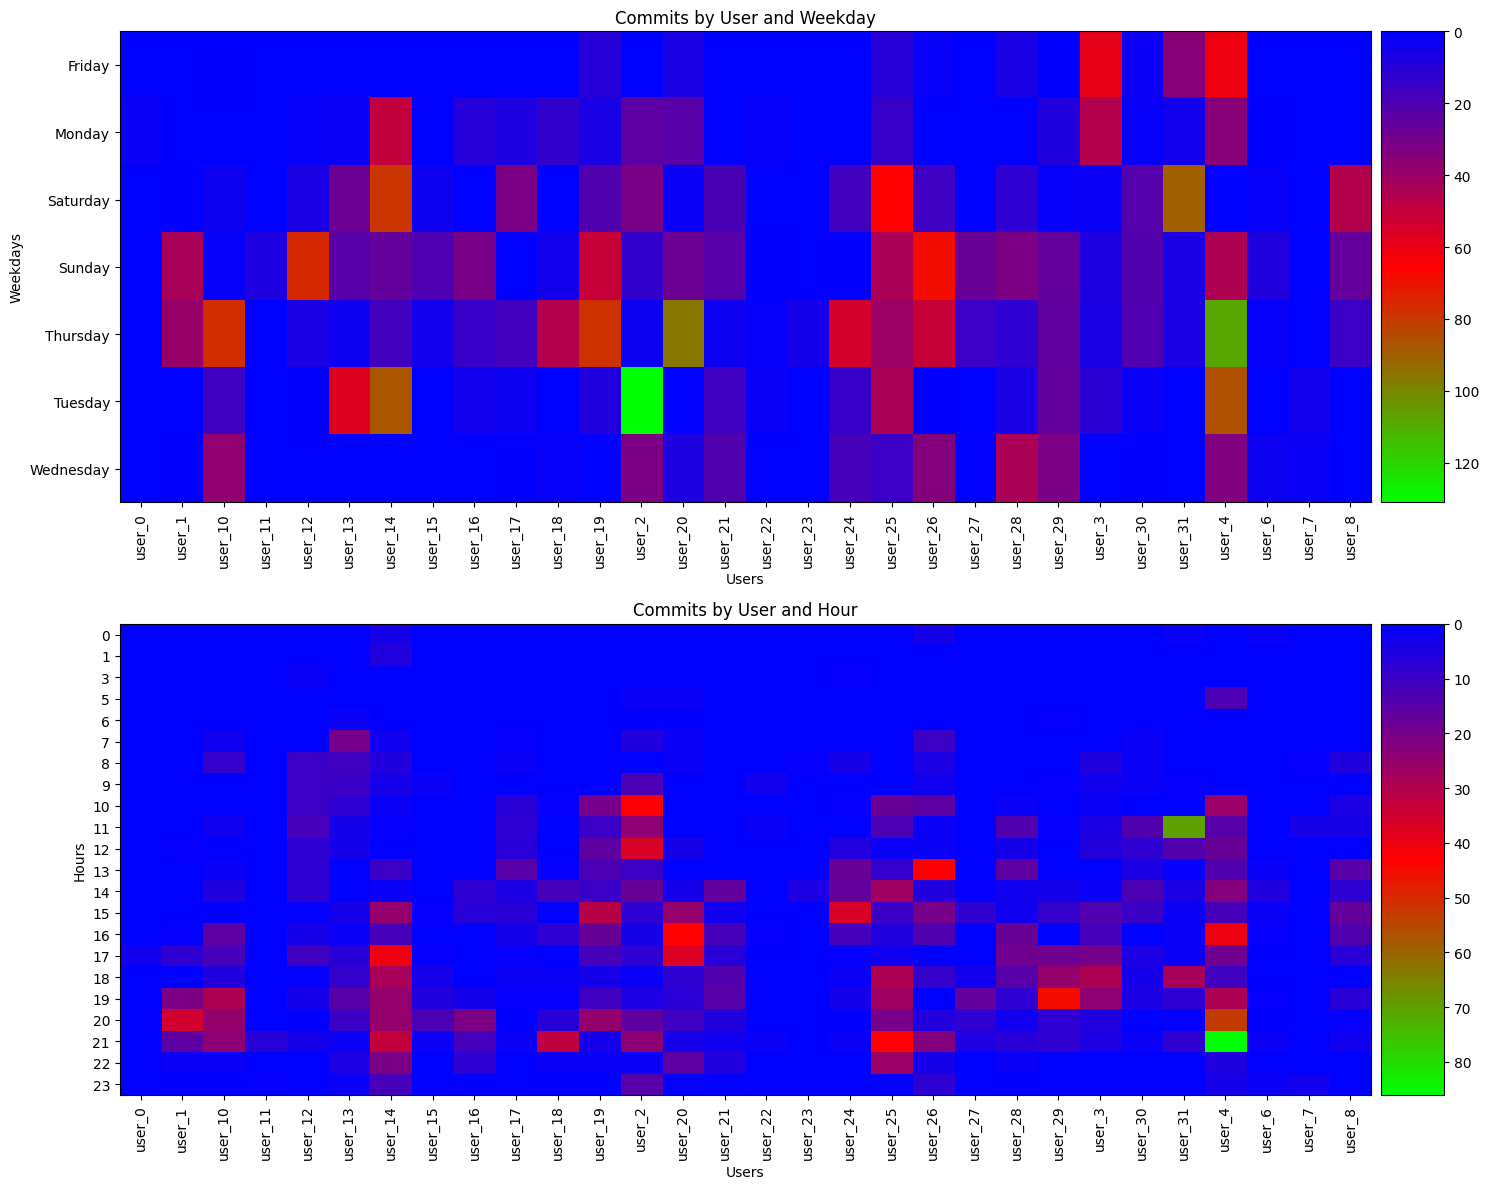

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(15, 12))
divider1 = make_axes_locatable(ax[0])
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
cax1.set_ylabel('Weekdays', rotation=270, labelpad=15)
cax1.imshow(user_final_days.values, aspect='auto', cmap='brg', interpolation='none')
ax[0].set_title('Commits by User and Weekday')
ax[0].set_xlabel('Users')
ax[0].set_ylabel('Weekdays')
ax[0].set_xticks(range(len(user_final_days.columns)))
ax[0].set_xticklabels(user_final_days.columns, rotation=90)
ax[0].set_yticks(range(len(user_final_days.index)))
ax[0].set_yticklabels(user_final_days.index)

fig.colorbar(ax[0].imshow(user_final_days.values, aspect='auto', cmap='brg', interpolation='nearest'), cax=cax1)

divider2 = make_axes_locatable(ax[1])
cax2 = divider2.append_axes("right", size="5%", pad=0.1)
cax2.set_ylabel('Hours', rotation=270, labelpad=15)
cax2.imshow(user_final_hours.values, aspect='auto', cmap='brg', interpolation='none')
ax[1].set_title('Commits by User and Hour')
ax[1].set_xlabel('Users')
ax[1].set_ylabel('Hours')
ax[1].set_xticks(range(len(user_final_hours.columns)))
ax[1].set_xticklabels(user_final_hours.columns, rotation=90)
ax[1].set_yticks(range(len(user_final_hours.index)))
ax[1].set_yticklabels(user_final_hours.index)

plt.subplots_adjust(hspace=0.4)

fig.colorbar(ax[1].imshow(user_final_hours.values, aspect='auto', cmap='brg', interpolation='nearest'), cax=cax2)

plt.tight_layout()
plt.show()

## Which user has the most commits on Tue?
#### user_2
## Which user has the most commits on Thu?
#### user_4
## On which weekday do the users not like making a lot of commits?
#### friday
## Which user at which hour made the largest number of commits?
#### user_26, 0 | user_14, 1 | user_12, 3 | user_4, 5 | user_13, 6 | user_13, 7 | user_13, 8 | user_2, 9 | user_2, 10 | user_4, 11 | user_2, 12
#### user_26, 13 | user_25, 14 | user_24, 15 | user_4, 16 | user_14, 17 | user_14, 18 | user_29, 19 | user_4, 20 | user_4, 21 | user_25, 22 | user_2, 23


